# Chatbot Interaction — Data Preprocessing
### HCI Research Project | Systematic Literature Review (55 Papers)
---

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Load the Dataset

In [2]:
# Load the binary-coded literature matrix
df = pd.read_excel(
    'Chatbot Binary Dataset.xlsx',
    sheet_name='Binary_Coded_Dataset',
    header=1  # Row 2 contains actual column names
)

print('Dataset loaded!')
print(f'Shape: {df.shape}  ({df.shape[0]} papers, {df.shape[1]} columns)')
print(f'\nColumn names:')
print(list(df.columns))

Dataset loaded!
Shape: (55, 24)  (55 papers, 24 columns)

Column names:
['Paper_ID', 'Year', 'Industry', 'Quantitative', 'Qualitative', 'Mixed', 'Small_Sample', 'Medium_Sample', 'Large_Sample', 'Response_Accuracy', 'Reliability', 'Personalization', 'Ease_of_Use', 'Transparency', 'Social_Presence', 'Anthropomorphism', 'Trust', 'Privacy_Concern', 'Prior_Experience', 'Digital_Literacy', 'High_Task_Complexity', 'Sensitive_Industry', 'Satisfaction', 'Continued_Use']


In [ ]:
# Preview first 5 rows
df.head()

## Step 3: Data Cleaning
### 3a. Check for Duplicate Rows

In [3]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

# Remove duplicates if any
df.drop_duplicates(inplace=True)
print(f'Rows after removing duplicates: {len(df)}')

Number of duplicate rows: 0
Rows after removing duplicates: 55


### 3b. Check for Missing Values

In [4]:
print('=== Missing Values Per Column ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing cells: {missing.sum()}')

=== Missing Values Per Column ===
Paper_ID                0
Year                    0
Industry                0
Quantitative            0
Qualitative             0
Mixed                   0
Small_Sample            0
Medium_Sample           0
Large_Sample            0
Response_Accuracy       0
Reliability             0
Personalization         0
Ease_of_Use             0
Transparency            0
Social_Presence         0
Anthropomorphism        0
Trust                   0
Privacy_Concern         0
Prior_Experience        0
Digital_Literacy        0
High_Task_Complexity    0
Sensitive_Industry      0
Satisfaction            0
Continued_Use           0
dtype: int64

Total missing cells: 0


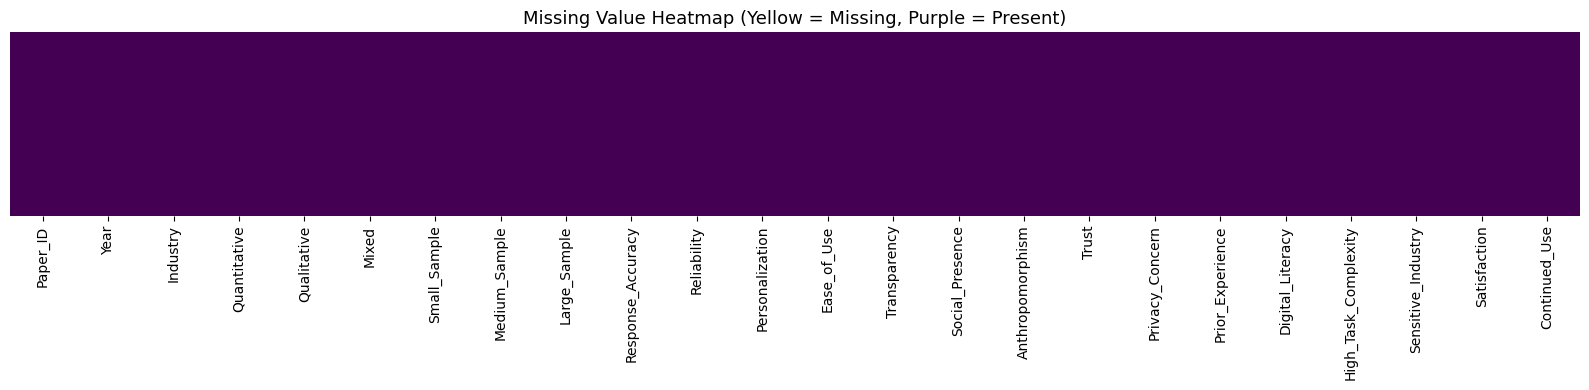

Green = data present. No yellow bands = no missing values.


In [5]:
# Visualize missing values as a heatmap
plt.figure(figsize=(16, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Missing Value Heatmap (Yellow = Missing, Purple = Present)', fontsize=13)
plt.tight_layout()
plt.show()
print('Green = data present. No yellow bands = no missing values.')

### 3c. Handle Missing Values

In [6]:
binary_cols = [c for c in df.columns if c not in ['Paper_ID', 'Year', 'Industry']]

# Binary columns: fill NaN with 0 (feature not studied = absent)
for col in binary_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

# Industry: fill with 'Unknown'
df['Industry'].fillna('Unknown', inplace=True)

# Year: fill with median
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').fillna(df['Year'].median())

print(f'Missing values after handling: {df.isnull().sum().sum()}')
print('All missing values handled!')

Missing values after handling: 0
All missing values handled!


### 3d. Check Data Types

In [7]:
print('=== Data Types ===')
print(df.dtypes)

=== Data Types ===
Paper_ID                object
Year                     int64
Industry                object
Quantitative             int64
Qualitative              int64
Mixed                    int64
Small_Sample             int64
Medium_Sample            int64
Large_Sample             int64
Response_Accuracy        int64
Reliability              int64
Personalization          int64
Ease_of_Use              int64
Transparency             int64
Social_Presence          int64
Anthropomorphism         int64
Trust                    int64
Privacy_Concern          int64
Prior_Experience         int64
Digital_Literacy         int64
High_Task_Complexity     int64
Sensitive_Industry       int64
Satisfaction             int64
Continued_Use            int64
dtype: object


### 3e. Check Class Balance (Target Variables)

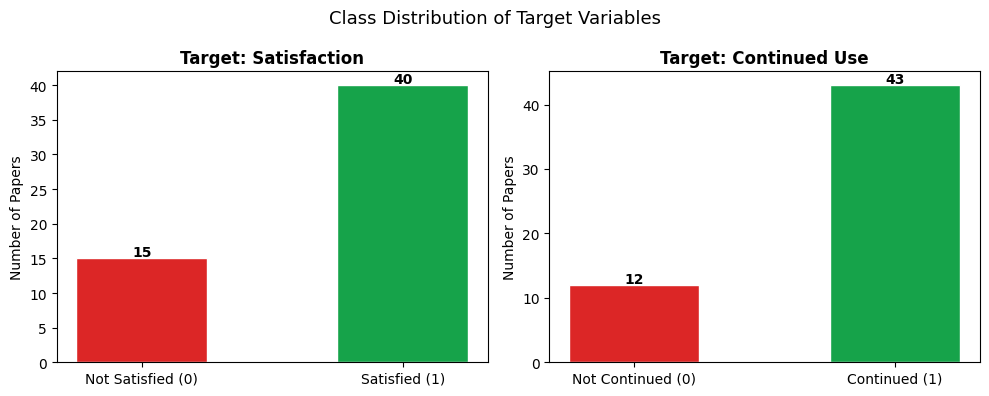

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Satisfaction distribution
sat_counts = df['Satisfaction'].value_counts()
axes[0].bar(['Not Satisfied (0)', 'Satisfied (1)'],
            [sat_counts.get(0,0), sat_counts.get(1,0)],
            color=['#DC2626', '#16A34A'], edgecolor='white', width=0.5)
axes[0].set_title('Target: Satisfaction', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Papers')
for i, v in enumerate([sat_counts.get(0,0), sat_counts.get(1,0)]):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# Continued Use distribution
cu_counts = df['Continued_Use'].value_counts()
axes[1].bar(['Not Continued (0)', 'Continued (1)'],
            [cu_counts.get(0,0), cu_counts.get(1,0)],
            color=['#DC2626', '#16A34A'], edgecolor='white', width=0.5)
axes[1].set_title('Target: Continued Use', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Papers')
for i, v in enumerate([cu_counts.get(0,0), cu_counts.get(1,0)]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('Class Distribution of Target Variables', fontsize=13)
plt.tight_layout()
plt.show()

## Step 4: Data Transformation
### 4a. Label Encoding — Convert Industry (Text → Number)

In [9]:
le = LabelEncoder()
df['Industry_Encoded'] = le.fit_transform(df['Industry'])

# Show encoding mapping
mapping = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
print('=== Industry Label Encoding ===')
for industry, code in mapping.items():
    print(f'  {industry:20s} → {code}')

=== Industry Label Encoding ===
  Banking              → 0
  Cybersecurity        → 1
  Digital Marketing    → 2
  E-Commerce           → 3
  Education            → 4
  General              → 5
  General/NLP          → 6
  Healthcare           → 7
  Multi-domain         → 8
  Retail               → 9
  Services             → 10
  Technology           → 11
  Tourism              → 12


### 4b. Descriptive Statistics After Transformation

In [10]:
print('=== Descriptive Statistics (Binary Features) ===')
df[binary_cols].describe().round(2)

=== Descriptive Statistics (Binary Features) ===


,Quantitative,Qualitative,Mixed,Small_Sample,Medium_Sample,Large_Sample,Response_Accuracy,Reliability,Personalization,Ease_of_Use,...,Social_Presence,Anthropomorphism,Trust,Privacy_Concern,Prior_Experience,Digital_Literacy,High_Task_Complexity,Sensitive_Industry,Satisfaction,Continued_Use
count,55.00,55.00,55.00,55.0,55.00,55.00,55.00,55.00,55.00,55.00,...,55.00,55.00,55.00,55.00,55.00,55.00,55.0,55.00,55.00,55.00
mean,0.82,0.42,0.24,0.2,0.40,0.31,0.93,0.84,0.47,0.40,...,0.51,0.69,0.42,0.45,0.62,0.49,0.8,0.16,0.73,0.78
std,0.39,0.50,0.43,0.4,0.49,0.47,0.26,0.37,0.50,0.49,...,0.50,0.47,0.50,0.50,0.49,0.50,0.4,0.37,0.45,0.42
min,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,1.00,0.00,0.00,0.0,0.00,0.00,1.00,1.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,1.0,0.00,0.00,1.00
50%,1.00,0.00,0.00,0.0,0.00,0.00,1.00,1.00,0.00,0.00,...,1.00,1.00,0.00,0.00,1.00,0.00,1.0,0.00,1.00,1.00
75%,1.00,1.00,0.00,0.0,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.0,0.00,1.00,1.00
max,1.00,1.00,1.00,1.0,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.0,1.00,1.00,1.00


## Step 5: Exploratory Data Analysis (EDA)
### 5a. Feature Frequency — How Often Each Feature Was Studied

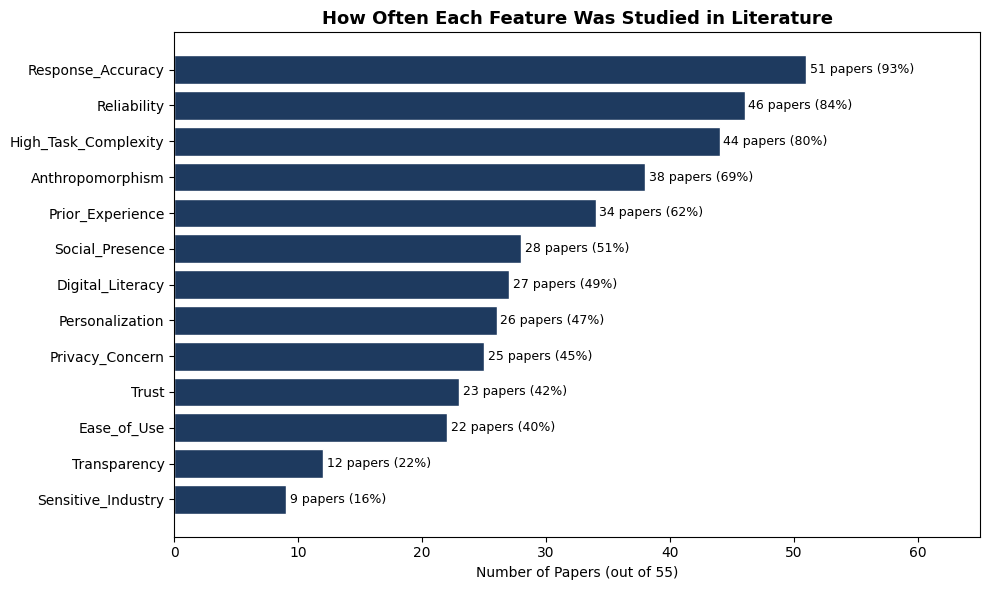

In [11]:
chatbot_features = [
    'Response_Accuracy', 'Reliability', 'Personalization', 'Ease_of_Use',
    'Transparency', 'Social_Presence', 'Anthropomorphism',
    'Trust', 'Privacy_Concern', 'Prior_Experience', 'Digital_Literacy',
    'High_Task_Complexity', 'Sensitive_Industry'
]

freq = df[chatbot_features].sum().sort_values(ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(freq.index, freq.values, color='#1E3A5F', edgecolor='white')
for bar, val in zip(bars, freq.values):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val} papers ({val/55*100:.0f}%)', va='center', fontsize=9)
plt.xlabel('Number of Papers (out of 55)')
plt.title('How Often Each Feature Was Studied in Literature', fontsize=13, fontweight='bold')
plt.xlim(0, 65)
plt.tight_layout()
plt.show()

### 5b. Correlation Heatmap of All Features

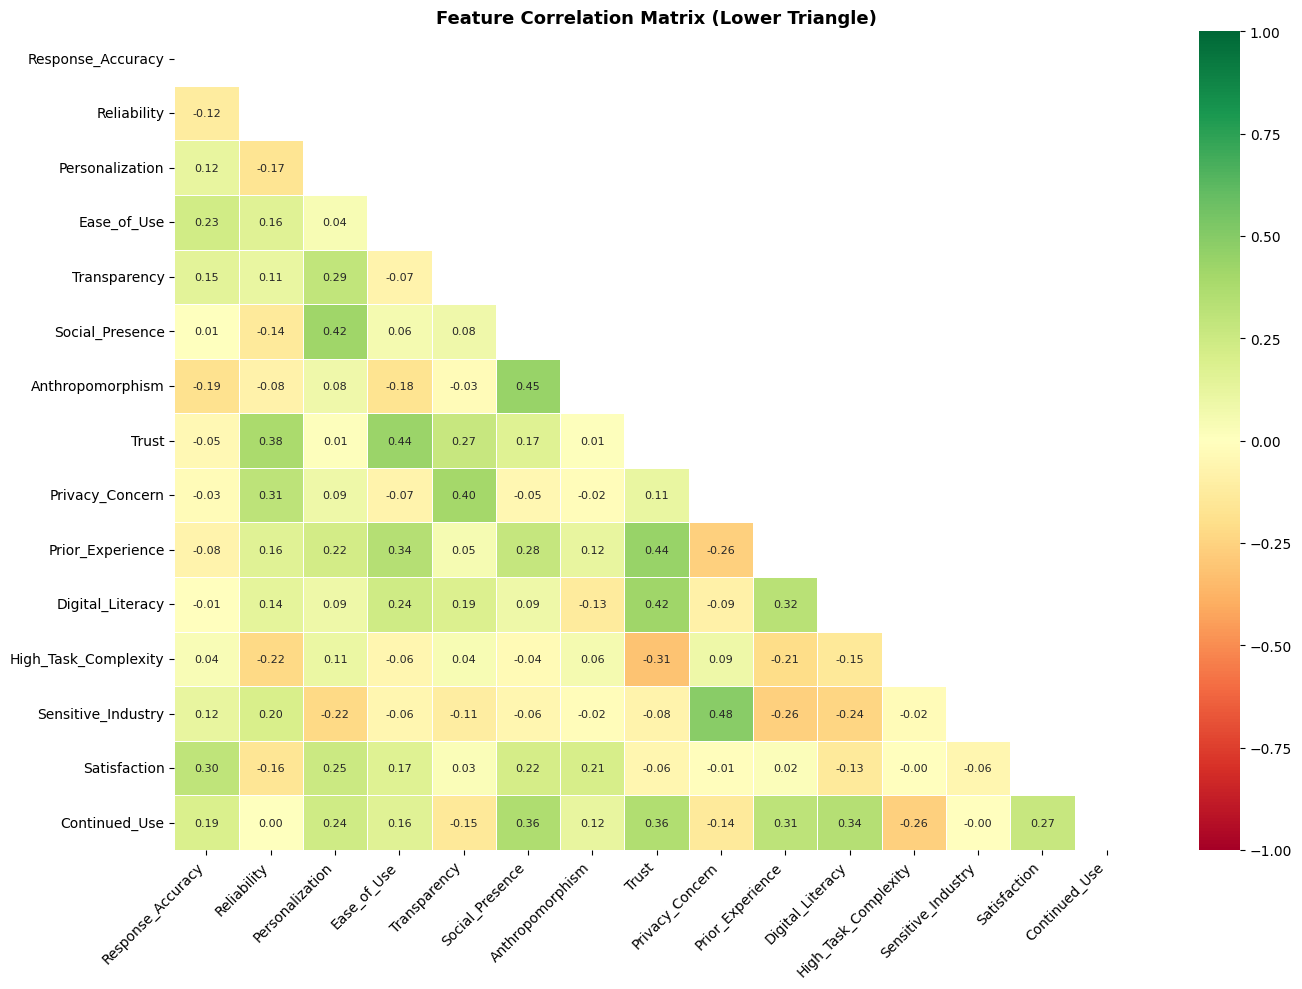

Green = positive correlation. Red = negative correlation.


In [12]:
plt.figure(figsize=(14, 10))
corr = df[chatbot_features + ['Satisfaction', 'Continued_Use']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print('Green = positive correlation. Red = negative correlation.')

### 5c. Industry Distribution

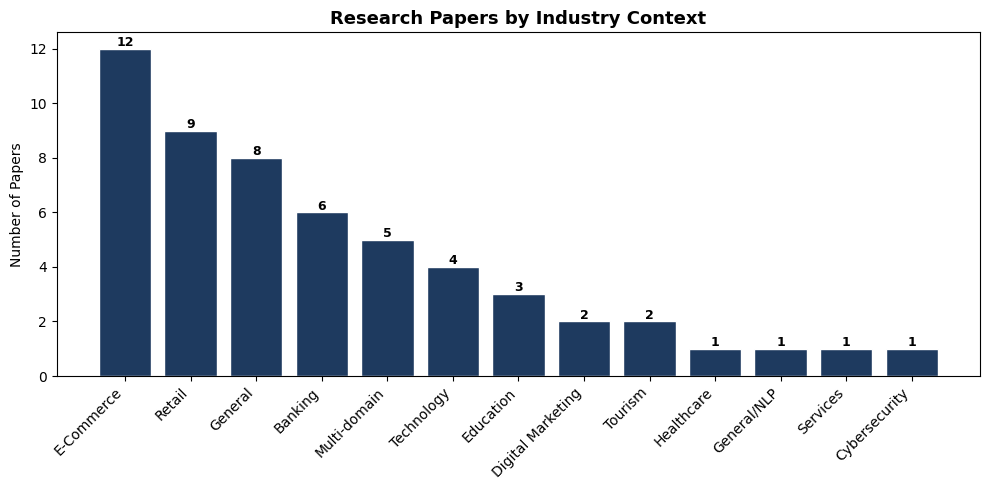

In [13]:
ind_counts = df['Industry'].value_counts()

plt.figure(figsize=(10, 5))
bars = plt.bar(ind_counts.index, ind_counts.values,
               color='#1E3A5F', edgecolor='white')
for bar, val in zip(bars, ind_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.1,
             str(val), ha='center', fontweight='bold', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Papers')
plt.title('Research Papers by Industry Context', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5d. Publication Year Trend

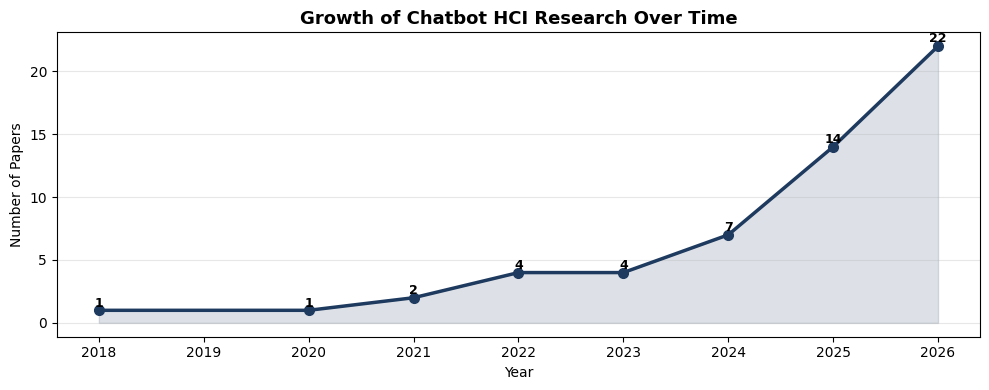

In [14]:
year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(year_counts.index, year_counts.values,
         marker='o', color='#1E3A5F', linewidth=2.5, markersize=7)
plt.fill_between(year_counts.index, year_counts.values,
                 alpha=0.15, color='#1E3A5F')
for x, y in zip(year_counts.index, year_counts.values):
    plt.text(x, y + 0.3, str(y), ha='center', fontweight='bold', fontsize=9)
plt.xlabel('Year')
plt.ylabel('Number of Papers')
plt.title('Growth of Chatbot HCI Research Over Time', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Step 6: Final Preprocessed Dataset

In [15]:
print('=== PREPROCESSING COMPLETE ===')
print(f'Final dataset shape : {df.shape}')
print(f'Total papers        : {len(df)}')
print(f'Total features      : {df.shape[1]}')
print(f'Missing values      : {df.isnull().sum().sum()}')
print(f'Duplicate rows      : {df.duplicated().sum()}')
print(f'Binary features     : {len(binary_cols)}')
print(f'Categorical encoded : Industry → Industry_Encoded')
print('\nReady for Machine Learning!')

=== PREPROCESSING COMPLETE ===
Final dataset shape : (55, 25)
Total papers        : 55
Total features      : 25
Missing values      : 0
Duplicate rows      : 0
Binary features     : 21
Categorical encoded : Industry → Industry_Encoded

Ready for Machine Learning!


In [16]:
# Save the preprocessed dataset
df.to_excel('Chatbot_Preprocessed_ML_Ready.xlsx', index=False)
print('Preprocessed dataset saved as: Chatbot_Preprocessed_ML_Ready.xlsx')

# Preview final dataset
df.head(10)

Preprocessed dataset saved as: Chatbot_Preprocessed_ML_Ready.xlsx


,Paper_ID,Year,Industry,Quantitative,Qualitative,Mixed,Small_Sample,Medium_Sample,Large_Sample,Response_Accuracy,...,Anthropomorphism,Trust,Privacy_Concern,Prior_Experience,Digital_Literacy,High_Task_Complexity,Sensitive_Industry,Satisfaction,Continued_Use,Industry_Encoded
0,P1,2026,E-Commerce,1,0,0,0,1,0,1,...,0,1,1,1,1,0,0,1,1,3
1,P2,2022,Banking,0,1,0,1,0,0,1,...,0,0,1,0,0,1,1,1,1,0
2,P3,2026,E-Commerce,0,1,0,1,0,0,1,...,1,1,1,1,1,1,0,1,1,3
3,P4,2025,General/NLP,1,0,0,0,0,1,1,...,0,0,0,0,0,1,0,0,0,6
4,P5,2025,Multi-domain,1,1,1,0,0,1,1,...,0,0,1,0,0,1,0,0,0,8
5,P6,2026,Healthcare,1,1,1,1,0,0,1,...,1,0,1,0,0,0,1,1,1,7
6,P7,2023,E-Commerce,1,0,0,0,1,0,1,...,0,0,0,0,0,1,0,1,1,3
7,P8,2021,Multi-domain,1,1,1,0,0,1,1,...,1,1,1,1,1,1,0,1,1,8
8,P9,2020,Services,1,1,1,0,1,0,0,...,1,0,1,0,0,1,0,1,0,10
9,P10,2024,Retail,1,0,0,0,0,1,1,...,1,1,0,1,0,1,0,1,1,9
